<a href="https://www.kaggle.com/code/mashrur135/nb-mae?scriptVersionId=341928686" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Task B — MAE (Masked Autoencoder) Pretraining
### CSE 438 Part B — SSL for Semantic Segmentation



In [1]:
import os, time, json, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Config cell

In [2]:
CONFIG = {
    "method": "MAE",
    "backbone": "ViT-custom (patch16)",
    "checkpoint_source": "from_scratch",   # from-scratch is common for MAE at this scale; state your choice
    "pretrain_epochs": 50,
    "batch_size": 32,             # ViT + full self-attention needs more memory than ResNet
    "img_size": 224,
    "patch_size": 16,
    "embed_dim": 384,
    "encoder_depth": 6,
    "encoder_heads": 6,
    "decoder_dim": 192,
    "decoder_depth": 2,
    "decoder_heads": 6,
    "mask_ratio": 0.75,            # report this -- key MAE hyperparameter
    "optimizer": "AdamW",
    "lr": 1.5e-4,
    "weight_decay": 0.04,
    "seed": 42,
}
CONFIG["num_patches"] = (CONFIG["img_size"] // CONFIG["patch_size"]) ** 2
CONFIG["grid_size"] = CONFIG["img_size"] // CONFIG["patch_size"]

random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"]); torch.cuda.manual_seed_all(CONFIG["seed"])

print(json.dumps(CONFIG, indent=2))


{
  "method": "MAE",
  "backbone": "ViT-custom (patch16)",
  "checkpoint_source": "from_scratch",
  "pretrain_epochs": 50,
  "batch_size": 32,
  "img_size": 224,
  "patch_size": 16,
  "embed_dim": 384,
  "encoder_depth": 6,
  "encoder_heads": 6,
  "decoder_dim": 192,
  "decoder_depth": 2,
  "decoder_heads": 6,
  "mask_ratio": 0.75,
  "optimizer": "AdamW",
  "lr": 0.00015,
  "weight_decay": 0.04,
  "seed": 42,
  "num_patches": 196,
  "grid_size": 14
}


## Load the verified split artifact from the Data Prep notebook

In [3]:
TRAIN_CSV = "/kaggle/input/notebooks/mashrur135/nb-01-data-prep/artifacts/splits/train_split.csv"

train_df = pd.read_csv(TRAIN_CSV)
print(f"Unlabelled pretraining images: {len(train_df)}")


Unlabelled pretraining images: 280


## MAE augmentation

MAE needs only ONE view per image (not two) -- masking itself provides the
learning signal, not a second augmented view. Mild augmentation only.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

mae_transform = T.Compose([
    T.RandomResizedCrop(CONFIG["img_size"], scale=(0.5, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),   # nadir aerial imagery -- no fixed "up"
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MAEDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["image_path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)   # single view

train_ds = MAEDataset(train_df, mae_transform)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=2, drop_last=True, pin_memory=True)
print(f"Batches per epoch: {len(train_loader)}")


Batches per epoch: 8


## Patch embedding + random masking



In [5]:
def patchify(imgs, patch_size):
    """[B, 3, H, W] -> [B, num_patches, patch_size*patch_size*3] raw pixel targets."""
    B, C, H, W = imgs.shape
    p = patch_size
    h = w = H // p
    x = imgs.reshape(B, C, h, p, w, p)
    x = torch.einsum('bchpwq->bhwpqc', x)   # -> [B, h, w, p, p, C]
    x = x.reshape(B, h * w, p * p * C)
    return x


def random_masking(x, mask_ratio):
    """
    x: [B, N, D] patch embeddings.
    Returns visible tokens, the binary mask (1 = masked), and the restore indices.
    """
    B, N, D = x.shape
    num_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)          # random shuffle per-sample
    ids_restore = torch.argsort(ids_shuffle, dim=1)     # how to undo the shuffle later

    ids_keep = ids_shuffle[:, :num_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)  # 1 = masked, 0 = visible, in ORIGINAL order

    return x_visible, mask, ids_restore


## MAE model: PatchEmbed -> Encoder (visible patches only) -> Decoder (reconstructs all patches)


In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                 # [B, embed_dim, grid, grid]
        x = x.flatten(2).transpose(1, 2)  # [B, num_patches, embed_dim]
        return x


class MAEModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patch_embed = PatchEmbed(cfg["img_size"], cfg["patch_size"], 3, cfg["embed_dim"])
        self.pos_embed = nn.Parameter(torch.zeros(1, cfg["num_patches"], cfg["embed_dim"]))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg["embed_dim"], nhead=cfg["encoder_heads"],
            dim_feedforward=cfg["embed_dim"] * 4, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg["encoder_depth"])

        # Decoder side: project to decoder dim, add mask tokens, decode, project back to pixels
        self.decoder_embed = nn.Linear(cfg["embed_dim"], cfg["decoder_dim"])
        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg["decoder_dim"]))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, cfg["num_patches"], cfg["decoder_dim"]))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg["decoder_dim"], nhead=cfg["decoder_heads"],
            dim_feedforward=cfg["decoder_dim"] * 4, batch_first=True)
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=cfg["decoder_depth"])

        patch_dim = cfg["patch_size"] * cfg["patch_size"] * 3
        self.decoder_pred = nn.Linear(cfg["decoder_dim"], patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward_encoder(self, imgs, mask_ratio):
        x = self.patch_embed(imgs) + self.pos_embed          # [B, N, embed_dim]
        x_visible, mask, ids_restore = random_masking(x, mask_ratio)
        latent = self.encoder(x_visible)                     # [B, num_visible, embed_dim] -- ONLY visible patches processed
        return latent, mask, ids_restore

    def forward_decoder(self, latent, ids_restore):
        x = self.decoder_embed(latent)                        # [B, num_visible, decoder_dim]
        B, N_total = ids_restore.shape
        num_visible = x.shape[1]

        mask_tokens = self.mask_token.repeat(B, N_total - num_visible, 1)
        x_full = torch.cat([x, mask_tokens], dim=1)            # [B, N_total, decoder_dim], visible first
        x_full = torch.gather(x_full, dim=1,
                               index=ids_restore.unsqueeze(-1).repeat(1, 1, x_full.shape[-1]))  # restore original order

        x_full = x_full + self.decoder_pos_embed
        x_full = self.decoder(x_full)
        pred = self.decoder_pred(x_full)                       # [B, N_total, patch_dim] -- reconstructed pixels
        return pred

    def forward(self, imgs, mask_ratio):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        target = patchify(imgs, self.cfg["patch_size"])
        return pred, target, mask

    def extract_feature_map(self, imgs):
        """Used later by Task C -- full forward pass, NO masking, returns a 2D grid."""
        x = self.patch_embed(imgs) + self.pos_embed
        latent = self.encoder(x)                               # [B, N, embed_dim], all patches visible
        grid = self.cfg["grid_size"]
        feature_map = latent.transpose(1, 2).reshape(
            imgs.shape[0], self.cfg["embed_dim"], grid, grid)   # -> [B, embed_dim, grid, grid] (the "adapter" reshape)
        return feature_map


model = MAEModel(CONFIG).to(DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG["img_size"], CONFIG["img_size"]).to(DEVICE)
    pred, target, mask = model(dummy, CONFIG["mask_ratio"])
    print(f"pred shape:   {pred.shape}")    # [2, num_patches, patch_dim]
    print(f"target shape: {target.shape}")  # [2, num_patches, patch_dim]
    print(f"mask shape:   {mask.shape}, fraction masked: {mask.mean().item():.2f}")

    fmap = model.extract_feature_map(dummy)
    print(f"Task C feature_map shape: {fmap.shape}")  # expect [2, embed_dim, 14, 14]


pred shape:   torch.Size([2, 196, 768])
target shape: torch.Size([2, 196, 768])
mask shape:   torch.Size([2, 196]), fraction masked: 0.75
Task C feature_map shape: torch.Size([2, 384, 14, 14])


## MAE loss


In [7]:
def mae_loss(pred, target, mask):
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)              # per-patch mean squared error, [B, N]
    loss = (loss * mask).sum() / mask.sum()  # average over MASKED patches only
    return loss


## Training loop (50 epochs)

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

loss_history, epoch_time_history = [], []

for epoch in range(CONFIG["pretrain_epochs"]):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    for imgs in train_loader:
        imgs = imgs.to(DEVICE)
        pred, target, mask = model(imgs, CONFIG["mask_ratio"])
        loss = mae_loss(pred, target, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    epoch_time = time.time() - t0
    loss_history.append(epoch_loss)
    epoch_time_history.append(epoch_time)

    print(f"Epoch {epoch+1}/{CONFIG['pretrain_epochs']} | Reconstruction MSE: {epoch_loss:.4f} | time: {epoch_time:.1f}s")


Epoch 1/50 | Reconstruction MSE: 1.0400 | time: 73.9s
Epoch 2/50 | Reconstruction MSE: 0.9037 | time: 60.4s
Epoch 3/50 | Reconstruction MSE: 0.8507 | time: 59.9s
Epoch 4/50 | Reconstruction MSE: 0.8228 | time: 60.2s
Epoch 5/50 | Reconstruction MSE: 0.8019 | time: 59.8s
Epoch 6/50 | Reconstruction MSE: 0.7922 | time: 60.0s
Epoch 7/50 | Reconstruction MSE: 0.7789 | time: 59.7s
Epoch 8/50 | Reconstruction MSE: 0.7785 | time: 59.6s
Epoch 9/50 | Reconstruction MSE: 0.7735 | time: 59.7s
Epoch 10/50 | Reconstruction MSE: 0.7766 | time: 60.0s
Epoch 11/50 | Reconstruction MSE: 0.7734 | time: 59.7s
Epoch 12/50 | Reconstruction MSE: 0.7833 | time: 59.2s
Epoch 13/50 | Reconstruction MSE: 0.7596 | time: 59.7s
Epoch 14/50 | Reconstruction MSE: 0.7515 | time: 59.9s
Epoch 15/50 | Reconstruction MSE: 0.7669 | time: 59.2s
Epoch 16/50 | Reconstruction MSE: 0.7626 | time: 59.8s
Epoch 17/50 | Reconstruction MSE: 0.7615 | time: 60.1s
Epoch 18/50 | Reconstruction MSE: 0.7803 | time: 59.7s
Epoch 19/50 | Recon

## Loss curve + per-epoch time (required for report)

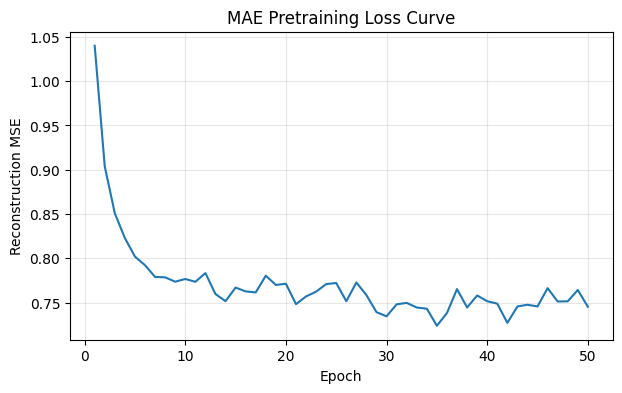

Average per-epoch time: 60.0s


In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel("Epoch"); plt.ylabel("Reconstruction MSE"); plt.title("MAE Pretraining Loss Curve")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/mae_pretrain_loss.png", dpi=150, bbox_inches="tight")
plt.show()

avg_epoch_time = sum(epoch_time_history) / len(epoch_time_history)
print(f"Average per-epoch time: {avg_epoch_time:.1f}s")


## Save encoder checkpoint for Task C



In [10]:
torch.save({
    "patch_embed_state_dict": model.patch_embed.state_dict(),
    "pos_embed": model.pos_embed,
    "encoder_state_dict": model.encoder.state_dict(),
    "config": CONFIG,
    "final_loss": loss_history[-1],
    "avg_epoch_time_sec": avg_epoch_time,
}, "/kaggle/working/mae_encoder_checkpoint.pth")

print("Saved: /kaggle/working/mae_encoder_checkpoint.pth")
print("Feeds Task C: use model.extract_feature_map() -> [B, embed_dim, 14, 14] into the ASPP decoder.")
print("Note: this IS the adapter -- token sequence reshaped to a 2D grid -- already built into extract_feature_map().")


Saved: /kaggle/working/mae_encoder_checkpoint.pth
Feeds Task C: use model.extract_feature_map() -> [B, embed_dim, 14, 14] into the ASPP decoder.
Note: this IS the adapter -- token sequence reshaped to a 2D grid -- already built into extract_feature_map().
